# 4. TDMA scheduling discussion

## 1. What this notebook solves

The previous notebook ended with the final candidate artifacts for one active bin. At that point, each active user already had a compact menu of valid full-frame operating rows taken from the stored frontier. This notebook continues directly from that point.

We now use those final candidate artifacts to explain the next step in the thesis story: how the TDMA scheduler selects one joint schedule for all users in one bin. The task is no longer to study one user in isolation. The task is to choose one row per active user so that the selected rows fit into one shared TDMA frame and still satisfy all user demands.

Among all feasible joint allocations, the scheduler returns the one with the lowest total frame-averaged PA DC input power.

In [1]:
import sys
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
%matplotlib inline

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

for path in (PROJECT_ROOT / "notebooks", PROJECT_ROOT / "src"):
    resolved = str(path.resolve())
    if resolved not in sys.path:
        sys.path.insert(0, resolved)

from configs.day_cycle import DEFAULT_SYNTHETIC_SESSION_GENERATION_CONFIG
from helpers.tdma_scheduling_helpers import TdmaSchedulingHelpers

DOC_IMG_DIR = PROJECT_ROOT / "img"
DOC_IMG_DIR.mkdir(parents=True, exist_ok=True)

# Notebook-wide visual identity: change this once to rerun for UPC theme.
helper = TdmaSchedulingHelpers(theme="aalto_elec")


In [2]:
artifacts = helper.build_artifacts(
    load_curve_csv=PROJECT_ROOT / "data" / "half_load_curve.csv",
    day_cycle_config=DEFAULT_SYNTHETIC_SESSION_GENERATION_CONFIG,
)


Saved figure to C:\Users\henry\Documents\Masters Thesis\code\img\tdma_scheduler_workflow.png


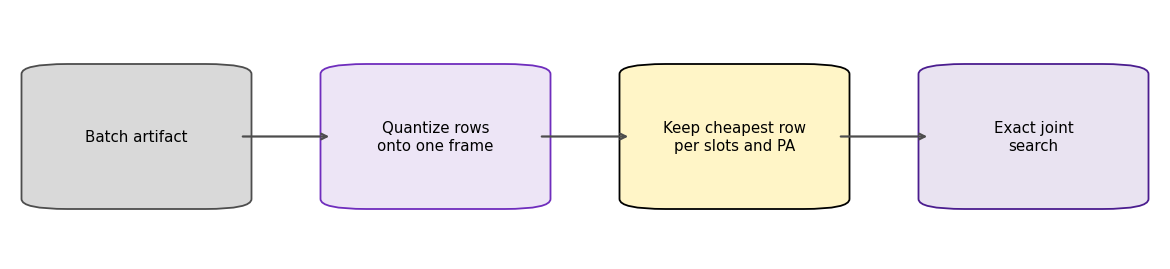

In [3]:
workflow_fig, workflow_ax = helper.plot_workflow(
    export_path=DOC_IMG_DIR / "tdma_scheduler_workflow.png",
)


The workflow starts from the cached batch artifact produced by the candidate-space stage. From that artifact, the scheduler first maps each user's full-frame rows onto the shared TDMA frame, then removes redundant TDMA rows, and only after that runs the exact joint search.

This figure shows the sequence of steps. It should be read from left to right: candidate artifacts enter the TDMA preparation stage, the prepared per-user menus define the exact search problem, and the solver returns one minimum-power joint allocation for the bin.

## 2. From cached full-frame menus to the search-ready TDMA tables

The scheduler starts from the cached per-user full-frame rows in the batch artifact. Each row describes a valid full-frame operating point for one user. To make these rows usable for shared TDMA scheduling, the scheduler maps each row onto the shared 20-slot frame,

$$
n_{\mathrm{slots}} = \left\lceil N_{\mathrm{frame}} \frac{R_{\mathrm{req}}}{R_{\mathrm{active}}} \right\rceil.
$$

Here, $n_{\mathrm{slots}}$ is the number of TDMA slots that the user would need on the shared frame, $N_{\mathrm{frame}}$ is the total number of slots in that frame, $R_{\mathrm{req}}$ is the user's required average rate over the frame, and $R_{\mathrm{active}}$ is the rate delivered while that row is active.

This mapping turns one full-frame operating point into one TDMA scheduling row. Each TDMA row then carries the schedule-facing quantities used by the exact search,

$$
R_{\mathrm{delivered}} = \frac{n_{\mathrm{slots}}}{N_{\mathrm{frame}}} R_{\mathrm{active}},
$$

$$
P_{\mathrm{DC,frame}} = \frac{n_{\mathrm{slots}}}{N_{\mathrm{frame}}} P_{\mathrm{DC,active}}.
$$

In these expressions, $R_{\mathrm{delivered}}$ is the average rate delivered over the shared frame, $P_{\mathrm{DC,frame}}$ is the frame-averaged PA DC power contribution of that row, and $P_{\mathrm{DC,active}}$ is the PA DC power while that row is active.

After quantization, the local TDMA prune keeps the minimum-power row for each slot count inside each PA family.

Saved figure to C:\Users\henry\Documents\Masters Thesis\code\img\tdma_scheduler_joint_search_space.png


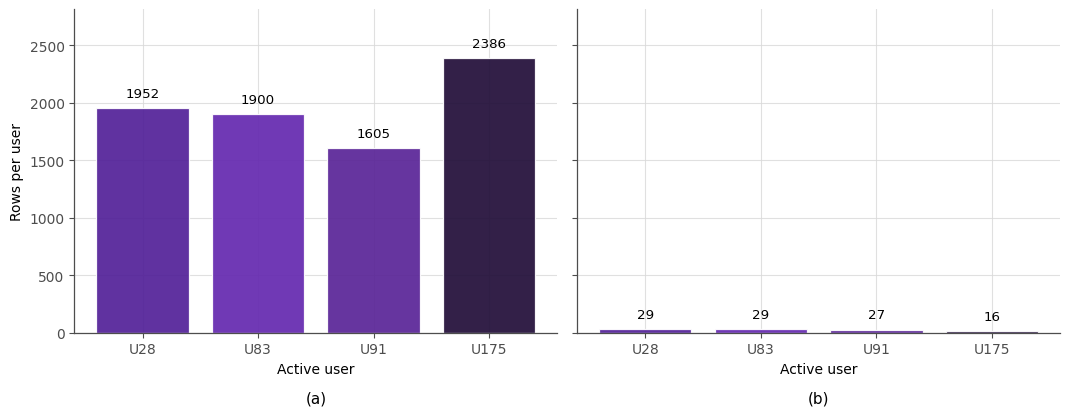

In [4]:
search_space_fig, search_space_axes = helper.plot_search_space_summary(
    artifacts,
    export_path=DOC_IMG_DIR / "tdma_scheduler_joint_search_space.png",
)


TDMA search-space reduction for the worked bin. Panel (a) shows the raw quantized per-user TDMA row counts. Read it as the size of the problem before scheduler-side pruning, which gives an implicit joint search size of `1,952 x 1,900 x 1,605 x 2,386 = 14,202,960,864,000` combinations. Panel (b) shows the prepared per-user tables after pruning, reducing that to `29 x 29 x 27 x 16 = 363,312` combinations.

The main point is that the scheduler does not start from a small problem by default. The preparation step is what turns the final candidate artifacts into a joint search problem that is still exact but small enough to solve directly.

Saved figure to C:\Users\henry\Documents\Masters Thesis\code\img\tdma_scheduler_quantized_spaces.png


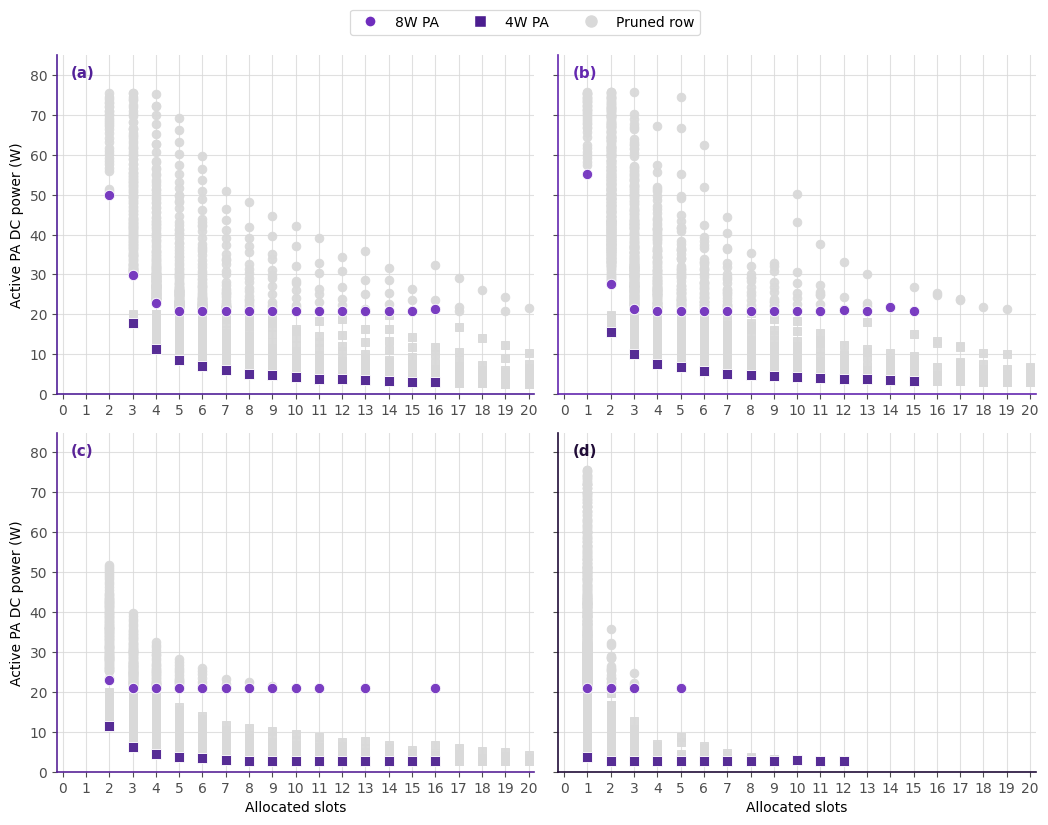

In [5]:
quantized_fig, quantized_axes = helper.plot_quantized_user_spaces(
    artifacts,
    export_path=DOC_IMG_DIR / "tdma_scheduler_quantized_spaces.png",
)


Per-user quantized and prepared TDMA menus for the worked bin. Panels (a)-(d) correspond to users `28`, `83`, `91`, and `175`, with requested rates of about `71`, `9`, `71`, and `6` Mbps at distances of `200`, `500`, `125`, and `200` m. Grey markers are rows removed before the exact search, either because a cheaper row with the same slot count already exists in the same PA family or because the row would overfill the frame once the other users' minimum slots are reserved. The colored markers are the rows that remain in the prepared exact-search problem, and none of those kept rows now consume all `20` slots.

This figure should be read user by user. For each panel, the grey rows show what became unnecessary after TDMA preparation, and the colored rows show the menu that is still available to the joint solver.

## 3. How the scheduler proves the optimal allocation

The exact solver never materializes the Cartesian product of the per-user TDMA tables. Instead, it searches over partial schedules. Each search depth fixes one more user row, updates the used-slot total, and updates the accumulated frame-averaged active PA DC cost.

The objective is to minimize the total frame-averaged active PA DC input power,

$$
\min \sum_u \frac{n_{\mathrm{slots},u}}{N_{\mathrm{frame}}} P_{\mathrm{DC,active},u}.
$$

In this objective, $u$ indexes users, $n_{\mathrm{slots},u}$ is the slot count assigned to user $u$, $N_{\mathrm{frame}}$ is the common frame size, and $P_{\mathrm{DC,active},u}$ is the active PA DC power of the selected row for user $u$.

A greedy pass provides the first feasible incumbent. Branch-and-bound then explores the user depths below and extends only the partial schedules that can still beat that incumbent. Because every full allocation is either evaluated directly or removed by an exact bound, the returned schedule is still the true optimum for this objective.

Saved figure to C:\Users\henry\Documents\Masters Thesis\code\img\tdma_scheduler_branch_and_bound_trace.png


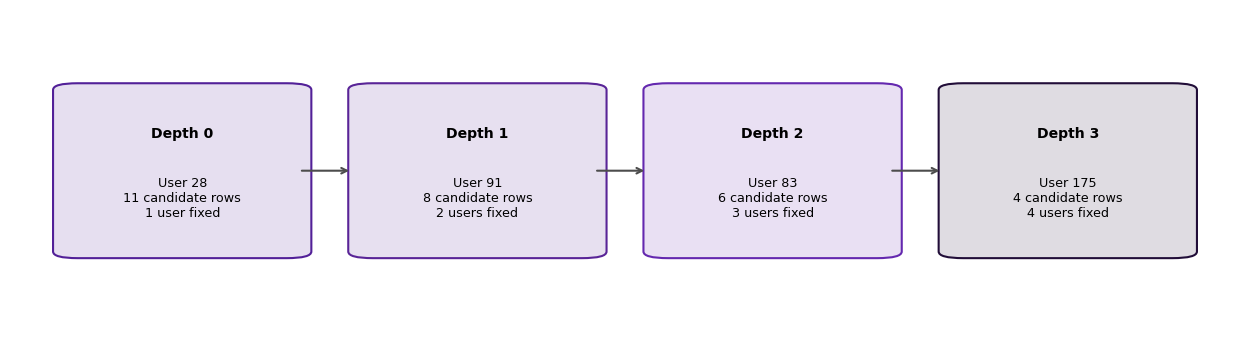

In [6]:
trace_fig, trace_ax = helper.plot_branch_and_bound_trace(
    artifacts,
    export_path=DOC_IMG_DIR / "tdma_scheduler_branch_and_bound_trace.png",
)


The solver descends one user at a time. At each depth it only expands the partial schedules that can still beat the current incumbent under the exact slot and power bounds.

This figure shows the logic of the search. It should be read from the root toward the leaves: each level fixes one more user choice, and branches disappear as soon as the bounds prove that they cannot lead to a better full schedule.

Saved figure to C:\Users\henry\Documents\Masters Thesis\code\img\tdma_scheduler_case_metrics.png


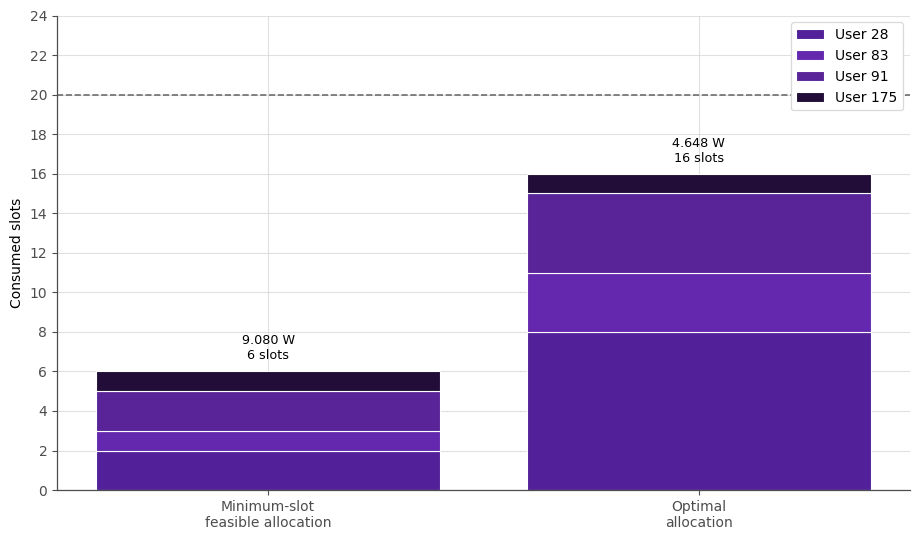

In [7]:
case_fig, case_ax = helper.plot_joint_search_case_metrics(
    artifacts,
    export_path=DOC_IMG_DIR / "tdma_scheduler_case_metrics.png",
)


Joint-allocation slot and power comparison for the two feasible worked-bin schedules. The minimum-slot solution uses only `6` slots, but it raises the frame-averaged PA DC power to about `9.08 W`. The returned optimum uses `16` slots, yet lowers the total frame-averaged PA DC power to about `4.65 W`.

The comparison shows how to read the scheduler objective. Fewer slots are not automatically better. What matters here is the total frame-averaged PA DC power of the full joint allocation.

## 4. How to read the scheduler output

The output is one optimal joint allocation for one active bin.

At the user level, the result tells us which TDMA row was selected for each user and how many slots that row occupies on the shared frame. At the frame level, it tells us how those selected rows fit together as one complete TDMA allocation, how many slots were used, and what total frame-averaged PA DC input power that joint solution consumes.

Showing the result on the TDMA frame makes the scheduler's decision visible: one selected row per user becomes one minimum-power allocation on the shared frame. The 3D view below keeps the same axes used earlier in the notebook: slot index, PRB index, and spatial layers.

Saved figure to C:\Users\henry\Documents\Masters Thesis\code\img\tdma_scheduler_selected_schedule_3d.png


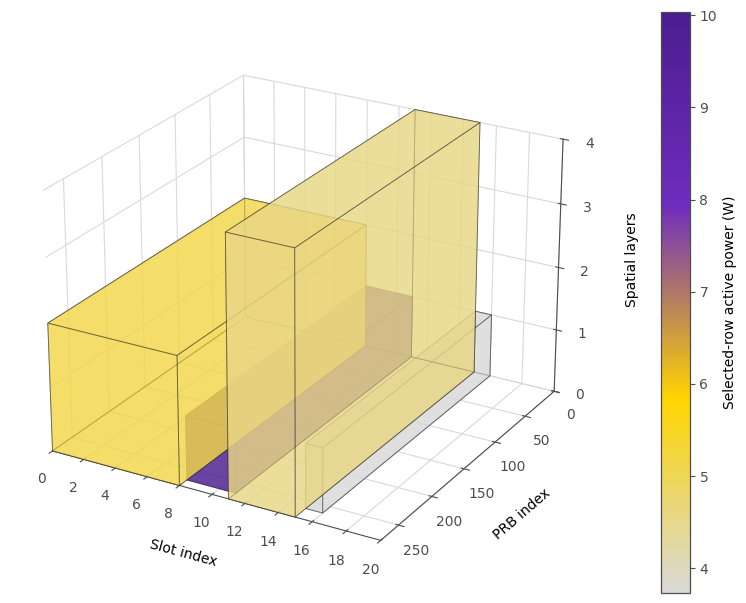

In [8]:
selected_schedule_fig, selected_schedule_ax = helper.plot_selected_schedule(
    artifacts,
    export_path=DOC_IMG_DIR / "tdma_scheduler_selected_schedule_3d.png",
)


Minimum-power allocation on the shared frame for the worked reference bin. Block length shows slot use, block depth shows occupied PRBs, block height shows spatial layers, and color shows the selected row's active PA power.

This figure should be read as the final packing of the chosen rows. Together, the blocks show how the joint schedule fits into one frame and which resource pattern the minimum-power solution actually uses.

## 5. Why this matters beyond one bin

The scheduler output is not fixed across the day. As the active user mix changes, the candidate rows that enter the joint search change with it. That changes the frame pressure and can change the minimum-power allocation.

The figure below keeps the worked reference bin and compares it against a more loaded bin later in the day. The heavier bin forces a different packing pattern and reaches a tighter frame occupancy.

The next notebook steps back from the scheduling mechanics and compares how these optimal allocations vary across the day and across scenario assumptions.

Saved figure to C:\Users\henry\Documents\Masters Thesis\code\img\tdma_scheduler_bin_transition_3d.png


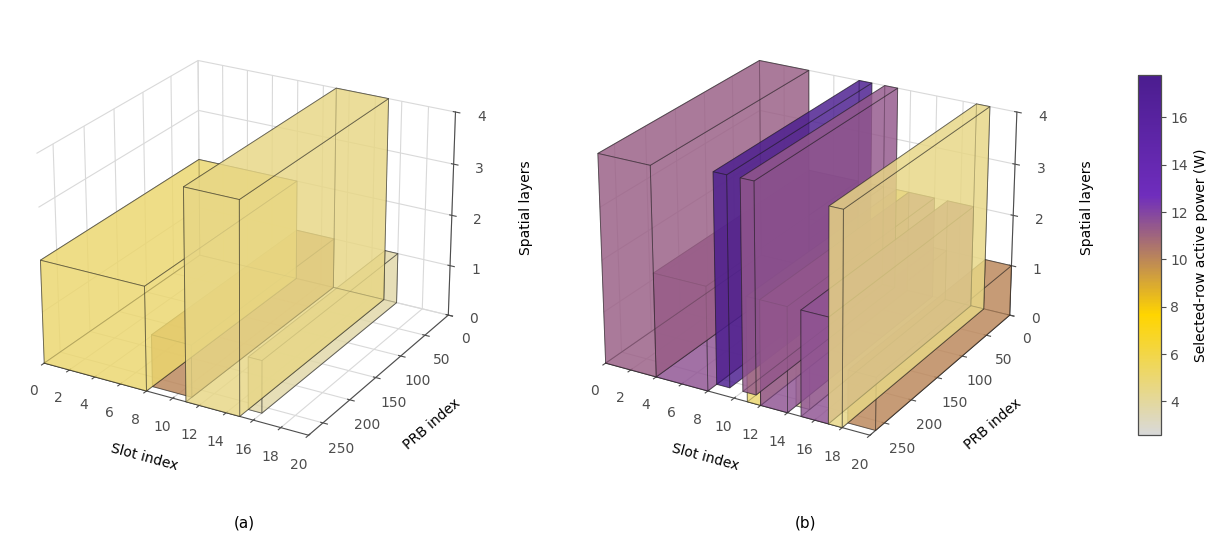

In [9]:
bin_transition_fig, bin_transition_axes = helper.plot_bin_transition(
    artifacts,
    export_path=DOC_IMG_DIR / "tdma_scheduler_bin_transition_3d.png",
)


Panels (a) and (b) compare the optimal 3D packing in the reference and higher-load bins. The reference bin carries `4` active users and about `157 Mbps` of requested rate, while the higher-load bin carries `11` users and about `246 Mbps`. In the heavier bin the optimal schedule fills all `20` slots and raises the frame-averaged schedule power from about `4.65 W` to about `10.13 W`.

The comparison shows what changes when the bin becomes more crowded. The same scheduler logic is used in both cases, but the feasible packing becomes tighter and the power cost of the optimal schedule increases.